In [51]:
# import DMeRates
import DMeRates.DMeRate as DMeRate
import torch
import numericalunits as nu
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True  # Enable LaTeX
params = {'text.usetex' : True,
            'font.size' : 12,
            'font.family' : 'cmr10',
            'figure.autolayout': True
            }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=10

First let's calculate the differential rate in Silicon using QCDark and QEDark form factors 

In [52]:
FDMn = 2
halo_model = 'shm'
DoScreen = False
test_mX = 10. #MeV
test_mX_eV = test_mX*1e6
test_mX_unitized= test_mX * nu.MeV / nu.c0**2
ne = 1
cs = 1e-36
cs_unitized = cs * nu.cm**2
nes = [1,2,3,4,5,6,7,8,9,10]
mX_array = np.concatenate((np.arange(0.2,0.8,0.025),np.array([0.9]),np.arange(1,5,0.05),np.arange(5,11,1),np.array([20,50,100,200,500,1000,10000]))) #MeV


In [53]:
import DMeRates
import DMeRates.DMeRate
dmrates_qedark = DMeRate.DMeRate('Si',QEDark=True)
dmrates = DMeRate.DMeRate('Si',QEDark=False)
dmrates.update_crosssection(cs)
dmrates_qedark.update_crosssection(cs)



dmrates_qedark.setup_halo_data(test_mX,FDMn,'shm')
dmrates.setup_halo_data(test_mX,FDMn,'shm')

# drde_qcdark_redo_res = dmrates.vectorized_dRdE(test_mX,FDMn,halo_model,DoScreen=DoScreen,integrate=True,unitize=True,debug=True) 
drde_qedark_redo = dmrates_qedark.vectorized_dRdE(test_mX,FDMn,'imb',DoScreen=DoScreen,integrate=False,unitize=True,debug=False).cpu().numpy()
drde_qcdark_redo = dmrates.vectorized_dRdE(test_mX,FDMn,'shm',DoScreen=DoScreen,integrate=True,unitize=True,debug=False).cpu().numpy()
dmrates.setup_halo_data(test_mX,FDMn,'modulated',isoangle=35,useVerne=True)

Earr = dmrates.Earr.cpu().numpy()
Earr /= nu.eV

Earr_qedark = dmrates_qedark.Earr.cpu().numpy()
Earr_qedark /= nu.eV


CUDA GPU found, performing calculations on GPU
CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\DMeRates\../form_factors/QCDark/Si_final.hdf5


c:\Users\Ansh\anaconda3\envs\dmerates\Lib\site-packages\torchquad\integration\simpson.py:76: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 1250 -> 1249.
  warnings.warn(


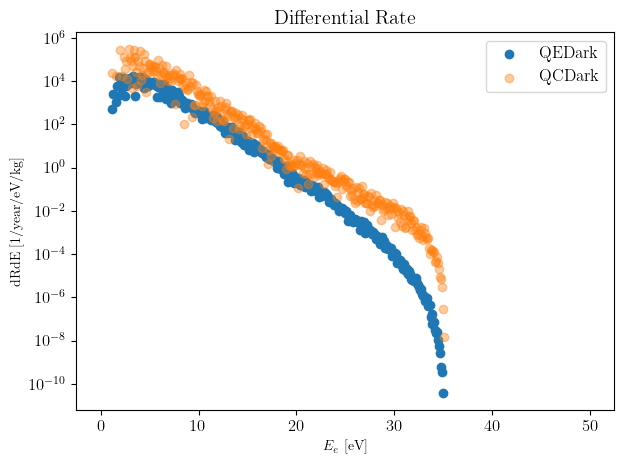

In [54]:


plt.scatter(Earr_qedark,drde_qedark_redo,label='QEDark')
plt.title('Differential Rate')
plt.ylabel("dRdE [1/year/eV/kg]")
plt.xlabel("$E_e$ [eV]")
plt.scatter(Earr,drde_qcdark_redo,label='QCDark',alpha=0.4)
plt.yscale('log')
plt.legend()
plt.show()
plt.close()




Next let's calculate rates for electron counts in Silicon

In [55]:
import DMeRates
import DMeRates.DMeRate as DMeRate
dmrates = DMeRate.DMeRate('Si',QEDark=False)
dmrates_qedark = DMeRate.DMeRate('Si',QEDark=True)

CUDA GPU found, performing calculations on GPU
Using form factor calculated from file: c:\Users\Ansh\Projects\DarkMatterRates\DMeRates\../form_factors/QCDark/Si_final.hdf5
CUDA GPU found, performing calculations on GPU


In [56]:

import time
start = time.time()
qcdark_redo = dmrates.calculate_rates(mX_array,'shm',FDMn,ne=nes,integrate=True,DoScreen=DoScreen)[ne-1] *nu.kg*nu.year
end = time.time()
print(f"took {end - start}s")
qedark_redo = dmrates_qedark.calculate_rates(mX_array,'imb',FDMn,ne=nes,integrate=False,DoScreen=DoScreen)[ne-1] *nu.kg*nu.year
end2 = time.time()
print(f"took {end2 - end}s")


took 0.6938164234161377s
took 0.2645895481109619s


<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_3120\4241805658.py:3: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("$m_\chi$ [MeV]")


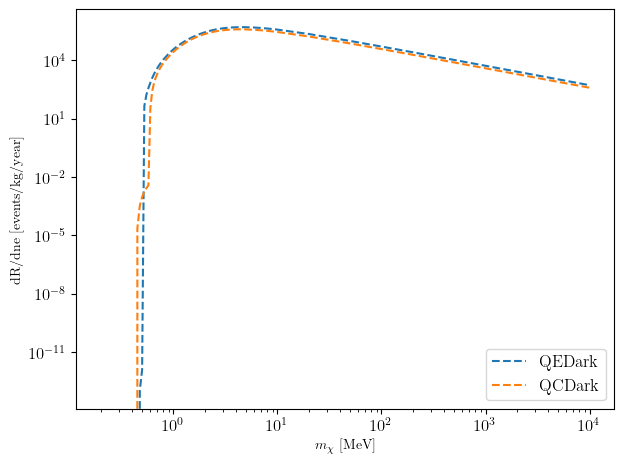

In [57]:
plt.plot(mX_array,qedark_redo.cpu().numpy(),label='QEDark',ls='--')
plt.plot(mX_array,qcdark_redo.cpu().numpy(),label='QCDark',ls='--')
plt.xlabel("$m_\chi$ [MeV]")
plt.ylabel("dR/dne [events/kg/year]")
plt.legend()
plt.xscale('log')
plt.yscale('log')

plt.show()
plt.close()

Example of how to generate your own modulated rates

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_3120\1082512471.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Isoangle $\circ$")


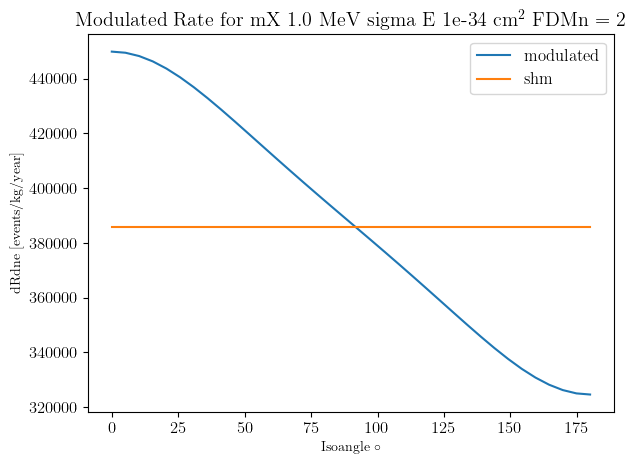

took 0.2808403968811035s


In [58]:
test_mX = 1.
test_cs = 1e-34
dmrates.update_crosssection(test_cs)
FDMn = 2
isoangles = np.linspace(0,180,36)
rate_per_angle = np.zeros(36)
rate_flat = np.zeros(36)
import time
start = time.time()
for isoangle in range(36):
    r = dmrates.calculate_rates(test_mX,'modulated',FDMn,ne=nes,integrate=True,DoScreen=True,isoangle=isoangle,useVerne=True)[ne-1] *nu.kg*nu.year
    rate_per_angle[isoangle] = r.cpu()
    r = dmrates.calculate_rates(test_mX,'shm',FDMn,ne=nes,integrate=True,DoScreen=True,isoangle=None)[ne-1] *nu.kg*nu.year
    rate_flat[isoangle] = r.cpu()
end = time.time()

plt.plot(isoangles,rate_per_angle,label='modulated')
plt.plot(isoangles,rate_flat,label='shm')
plt.title(f'Modulated Rate for mX {test_mX} MeV sigma E {test_cs} cm$^2$ FDMn = {FDMn} ')
plt.legend()
plt.xlabel("Isoangle $\circ$")
plt.ylabel("dRdne [events/kg/year]")
plt.show()
plt.close()
print(f"took {end - start}s")

Next let's do the same thing but for the noble liquid detectors (example is for Xenon, for Argon just change 'Xe' to 'Ar' below)

In [59]:
import DMeRates
import DMeRates.DMeRate as DMeRate
material = 'Xe'
dmrates = DMeRate.DMeRate(material)
import numpy as np

import numericalunits as nu
from DMeRates.Constants import *


CUDA GPU found, performing calculations on GPU


In [60]:
test_shell = '5p'
test_mX = 1000
test_mX_unitized = test_mX * nu.MeV / nu.c0**2
test_mX_eV = 1000*1e6

test_cs = 1e-34
FDMn = 0
halo_model = 'shm'

dmrates.update_crosssection(test_cs)

dmrates.setup_halo_data(test_mX,FDMn,'shm')

drs = dmrates.noble_dRdE(test_mX,FDMn,halo_model,halo_id_params=None,debug=False,unitize=True)
erec = dmrates.Earr.cpu().numpy() / nu.eV

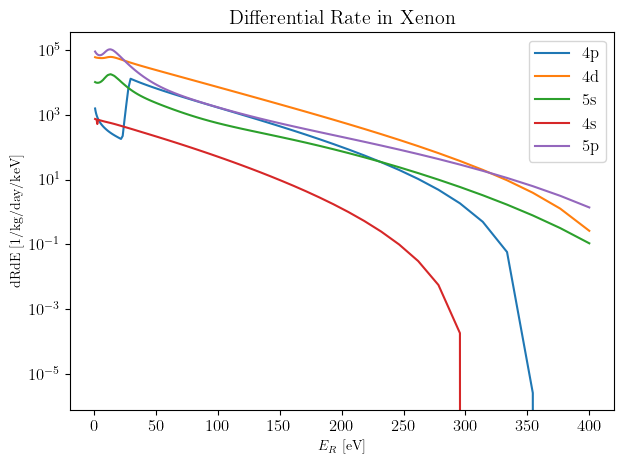

In [61]:
import matplotlib.pyplot as plt
import numericalunits as nu
for shell in dmrates.form_factor.keys:
    if shell in skip_keys[material]:
        continue
    plt.plot(erec,drs[shell].cpu().numpy(),label=f"{shell}")

plt.yscale('log')
plt.xlabel('$E_R$ [eV]')
plt.legend()
plt.ylabel("dRdE [1/kg/day/keV]")
plt.title("Differential Rate in Xenon")
plt.show()
plt.close()


In [62]:
import time
start = time.time()
nes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
rates_new_allsum = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=False)

rates_new_all,shells = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=True)
end = time.time()
print(f"took {end-start}s")
shells

took 0.03727531433105469s


['Summed', '4p', '4d', '5s', '4s', '5p']

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Ansh\AppData\Local\Temp\ipykernel_3120\2532094226.py:4: SyntaxWarning: invalid escape sequence '\c'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"
C:\Users\Ansh\AppData\Local\Temp\ipykernel_3120\2532094226.py:4: SyntaxWarning: invalid escape sequence '\s'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"


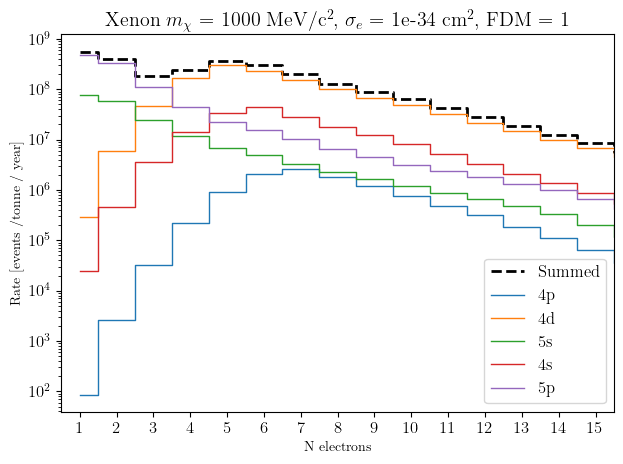

In [63]:
fdm_dict = {0: '1',
            2: '$1/q^2$'}
fdm_str = fdm_dict[FDMn]
title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}" 


plt.title('Xenon ' + title)# + (' -- SWAP 4s<->4p' if True else ''))


for i,key in enumerate(shells):
        ls = '--' if i == 0 else None
        c = 'k' if i ==0 else None
        lw = 2 if i == 0 else 1
        r = rates_new_all[0][:,i] * nu.tonne * nu.year
        r = r.cpu()
        nes = nes
        plt.plot(nes,r,drawstyle='steps-mid',label=key,ls=ls,c=c,lw=lw)
plt.xticks(np.arange(1, 16))
plt.xlim(0.5, 15.5)
plt.xlabel("N electrons")
plt.legend()
plt.yscale('log')
plt.ylabel(f"Rate [events /tonne / year]")

plt.show()
plt.close()

In [64]:
# 